In [1]:
import numpy as np
import os.path as osp
import matplotlib.pyplot as plt

In [159]:
OUTPUT_PATH = '/Users/alicansahin/Desktop/results_mp'
DATASET = 'csqa'
MODEL_NAME = 'qwen2_7b'
RESULTS_FOLDER = DATASET + '_' + MODEL_NAME
DATASET_PATH = osp.join(OUTPUT_PATH, RESULTS_FOLDER, 'martingale_check', 'ppr', 'martingale_results.npz')

In [27]:
dat = np.load('/Users/alicansahin/Desktop/martingale_results_j_40.npz', allow_pickle=True)
#dat = np.load(DATASET_PATH, allow_pickle=True)
dat = dat['42'].item()

In [13]:
for key in dat.keys():
    print(key, dat[key].shape)

distributions (10, 20, 21, 5)
true_labels (10,)
data_indices (10,)
input_texts (10,)
prompt_history (10, 20, 21)
K ()
mean_tv ()
pass_rate_tv_005 ()
pass_rate_tv_010 ()
mean_l1 ()
accuracy_at_p0 ()
tv_per_question (10,)
mean_l1_per_question (10,)
drift_profile (20,)
class_variance (10, 5)


In [33]:
dat['prompt_history'][0][0]

array(['Return the label of the correct answer for the question below.\n\nQuestion: Obstructing justice is sometimes an excuse used for police brutality which causes what in people?\nChoices:\nA) committing perjury\nB) prosecution\nC) attack\nD) getting hurt\nE) riot\nPreviously sampled answers: D, E, D, E, D, C, D, A, E, D',
       'Return the label of the correct answer for the question below.\n\nQuestion: Obstructing justice is sometimes an excuse used for police brutality which causes what in people?\nChoices:\nA) committing perjury\nB) prosecution\nC) attack\nD) getting hurt\nE) riot\nPreviously sampled answers: D, E, D, E, D, C, D, A, E, D, E\nCurrent belief distribution: A=33%, B=0%, C=0%, D=11%, E=56%.\nAnchor to this distribution and only update proportionally to new evidence.',
       'Return the label of the correct answer for the question below.\n\nQuestion: Obstructing justice is sometimes an excuse used for police brutality which causes what in people?\nChoices:\nA) commi

In [27]:
dat['prompt_history'][0][1]

array(['Return the label of the correct answer for the question below.\n\nQuestion: Obstructing justice is sometimes an excuse used for police brutality which causes what in people?\nChoices:\nA) committing perjury\nB) prosecution\nC) attack\nD) getting hurt\nE) riot\nPreviously sampled answers: D, B, D, D, B, E, E, E, D, D',
       'Return the label of the correct answer for the question below.\n\nQuestion: Obstructing justice is sometimes an excuse used for police brutality which causes what in people?\nChoices:\nA) committing perjury\nB) prosecution\nC) attack\nD) getting hurt\nE) riot\nPreviously sampled answers: D, B, D, D, B, E, E, E, D, D, C\nCurrent belief distribution: A=0%, B=0%, C=100%, D=0%, E=0%.\nAnchor to this distribution and only update proportionally to new evidence.',
       'Return the label of the correct answer for the question below.\n\nQuestion: Obstructing justice is sometimes an excuse used for police brutality which causes what in people?\nChoices:\nA) commit

In [25]:
dat['distributions'].shape

(10, 40, 21, 5)

In [21]:
p_all_averaged_over_J = dat['distributions'].mean(axis = 1)

In [22]:
p_0 = p_all_averaged_over_J[:,0,:]
p_others = p_all_averaged_over_J[:,1:,:]

logits shape: (10, 21, 5)


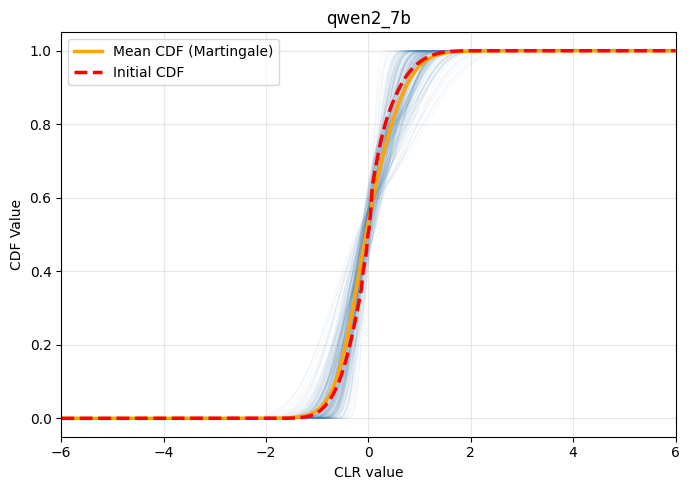

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.integrate import cumulative_trapezoid

eps = 1e-9

def to_clr(p):
    p = np.clip(p, eps, 1)
    log_p = np.log(p)
    logits = log_p - log_p.mean(axis=-1, keepdims=True)
    print("logits shape:", logits.shape)
    return logits

def smooth_cdf(values: np.ndarray, x_grid: np.ndarray, bw: float = 0.5) -> np.ndarray:
    """KDE-smoothed CDF; falls back to ECDF if data is degenerate."""
    if values.std() < 0.1:
        return np.mean(values[:, None] <= x_grid[None, :], axis=0).astype(float)
    try:
        kde     = gaussian_kde(values, bw_method=bw)
        density = kde(x_grid)
        cdf     = cumulative_trapezoid(density, x_grid, initial=0)
        cdf    /= cdf[-1]
        return cdf
    except np.linalg.LinAlgError:
        return np.mean(values[:, None] <= x_grid[None, :], axis=0).astype(float)

def mean_smooth_cdf(distributions_clr: np.ndarray, x_grid: np.ndarray, bw: float = 0.5) -> np.ndarray:
    """Mean KDE-smoothed CDF across N distributions (N, C)."""
    cdfs = np.array([smooth_cdf(dist, x_grid, bw) for dist in distributions_clr])
    return cdfs.mean(axis=0)


# --- Transform to CLR space ---
p_all_clr   = to_clr(p_all_averaged_over_J)
p_0_clr     = p_all_clr[:, 0, :]
p_steps_clr = p_all_clr[:, 1:, :]
blue_dists  = p_steps_clr.reshape(-1, p_steps_clr.shape[-1])   # (200, 5)

clip   = max(np.abs(blue_dists.max()), np.abs(p_0_clr.max()))
clip = 6
x_grid = np.linspace(-clip, clip, 400)

blue_clipped = np.clip(blue_dists, -clip, clip)
p0_clipped   = np.clip(p_0_clr,   -clip, clip)

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 5))

for dist in blue_clipped:
    try:
        cdf = smooth_cdf(dist, x_grid)
        ax.plot(x_grid, cdf, color='steelblue', alpha=0.06, linewidth=0.8)
    except Exception:
        pass

ax.plot(x_grid, mean_smooth_cdf(blue_clipped, x_grid),
        color='orange', linewidth=2.5, label='Mean CDF (Martingale)')

ax.plot(x_grid, mean_smooth_cdf(p0_clipped, x_grid),
        color='red', linestyle='--', linewidth=2.5, label='Initial CDF')

ax.set_xlabel("CLR value")
ax.set_ylabel("CDF Value")
ax.set_title('qwen2_7b')
ax.set_xlim(-clip, clip)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


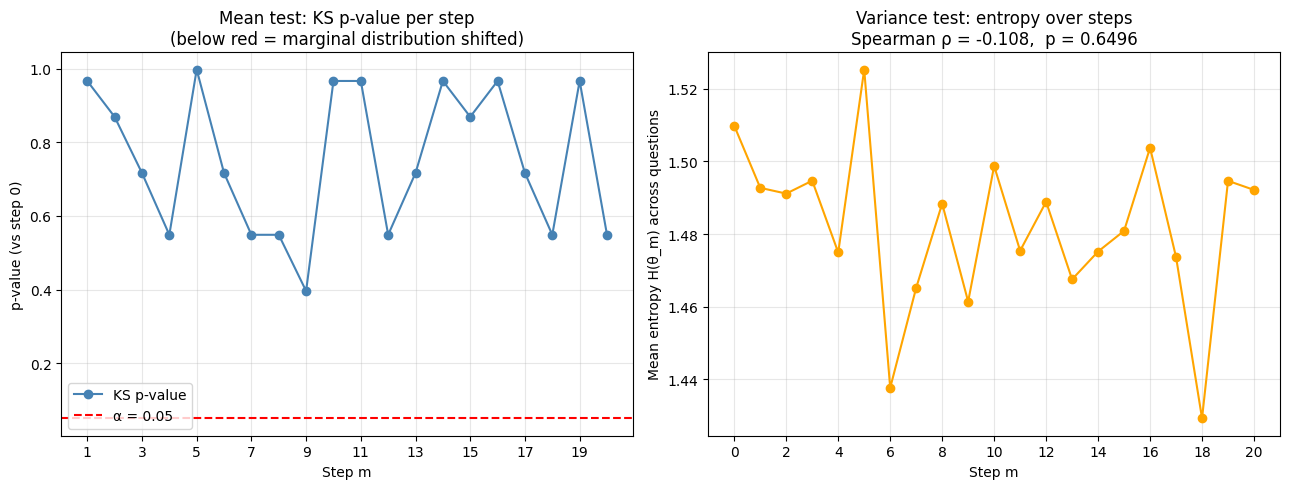

=== Mean test (KS on marginal distributions) ===
Steps with p < 0.05:  0 / 20
Martingale consistent:   YES

=== Variance test (entropy) ===
Spearman ρ = -0.1083,  p = 0.6496
Entropy tends to decrease but not significantly (p > α)


In [ ]:
## Try to understand here two distributions above is identical or not. Possible choices
##      1. KS test (scipy.stats.ks_2samp)
##      2. Wasserstein distance
##      3. For each blue draw, compute its distance to the Initial CDF (sup-norm, or L2/Cramér-von Mises distance ∫(F_draw − F_initial)² dx). 
##          This gives you an empirical null/reference distribution of "how far a single draw typically is from Initial."
##          Check where the Mean CDF's distance to Initial falls in that distribution. If it's well within the typical spread (e.g., not in the tail), you have no evidence the mean and initial CDFs differ.
##      4. Cramér-von Mises or Anderson-Darling (two-sample): more sensitive than KS to differences in the tails/bulk rather than just the single max gap.
##      5. Energy distance / Wasserstein distance: good if you care about overall distributional distance rather than a worst-case pointwise gap.

from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

def martingale_mean_var_tests(p_all: np.ndarray, alpha: float = 0.05):
    """
    p_all : (Q, T, C) — Q questions, T steps, C classes (already averaged over trajectories).

    Test 1 — Mean (KS): Under the martingale property E(theta_m) = const for all m.
    We compare the marginal distribution of theta_m at each step vs step 0 using
    a two-sample KS test on CLR-transformed values pooled over questions.

    Test 2 — Variance: Bayesian learning predicts epistemic uncertainty (entropy of
    theta_m averaged across questions) decreases monotonically with m.
    Tested via Spearman rank correlation between entropy and step index.
    """
    Q, T, C = p_all.shape
    steps = np.arange(T)

    # CLR transform
    eps = 1e-9
    p_c   = np.clip(p_all, eps, 1)
    log_p = np.log(p_c)
    p_clr = log_p - log_p.mean(axis=-1, keepdims=True)   # (Q, T, C)

    # --- Test 1: KS test — marginal distribution at step m vs step 0 ---
    ref      = p_clr[:, 0, :].ravel()   # (Q*C,)
    ks_pvals = np.ones(T)
    ks_stats = np.zeros(T)
    for m in range(1, T):
        curr = p_clr[:, m, :].ravel()
        ks_stats[m], ks_pvals[m] = stats.ks_2samp(ref, curr)

    # --- Test 2: Mean entropy per step (epistemic uncertainty) ---
    entropy      = -(p_all * np.log(p_c)).sum(axis=-1)   # (Q, T)
    mean_entropy = entropy.mean(axis=0)                   # (T,)
    rho, rho_pval = stats.spearmanr(steps[1:], mean_entropy[1:])

    # --- Plots ---
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    ax.plot(steps[1:], ks_pvals[1:], marker='o', color='steelblue', label='KS p-value')
    ax.axhline(alpha, color='red', linestyle='--', linewidth=1.5, label=f'α = {alpha}')
    ax.set_xlabel('Step m')
    ax.set_ylabel('p-value (vs step 0)')
    ax.set_title('Mean test: KS p-value per step\n(below red = marginal distribution shifted)')
    ax.set_xticks(steps[1:][::max(1, T // 10)])
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.plot(steps, mean_entropy, marker='o', color='orange')
    ax.set_xlabel('Step m')
    ax.set_ylabel('Mean entropy H(θ_m) across questions')
    ax.set_title(f'Variance test: entropy over steps\nSpearman ρ = {rho:.3f},  p = {rho_pval:.4f}')
    ax.set_xticks(steps[::max(1, T // 10)])
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # --- Summary ---
    n_sig = (ks_pvals[1:] < alpha).sum()
    print("=== Mean test (KS on marginal distributions) ===")
    print(f"Steps with p < {alpha}:  {n_sig} / {T - 1}")
    print(f"Martingale consistent:   {'YES' if n_sig == 0 else 'NO *'}")

    print("\n=== Variance test (entropy) ===")
    print(f"Spearman ρ = {rho:.4f},  p = {rho_pval:.4f}")
    if rho < 0 and rho_pval < alpha:
        print("Entropy decreases monotonically → consistent with Bayesian learning *")
    elif rho < 0:
        print("Entropy tends to decrease but not significantly (p > α)")
    else:
        print("Entropy does NOT decrease monotonically *")

# p_all = dat['distributions'].mean(axis=1) → (Q, T, C)
martingale_mean_var_tests(p_all_averaged_over_J)


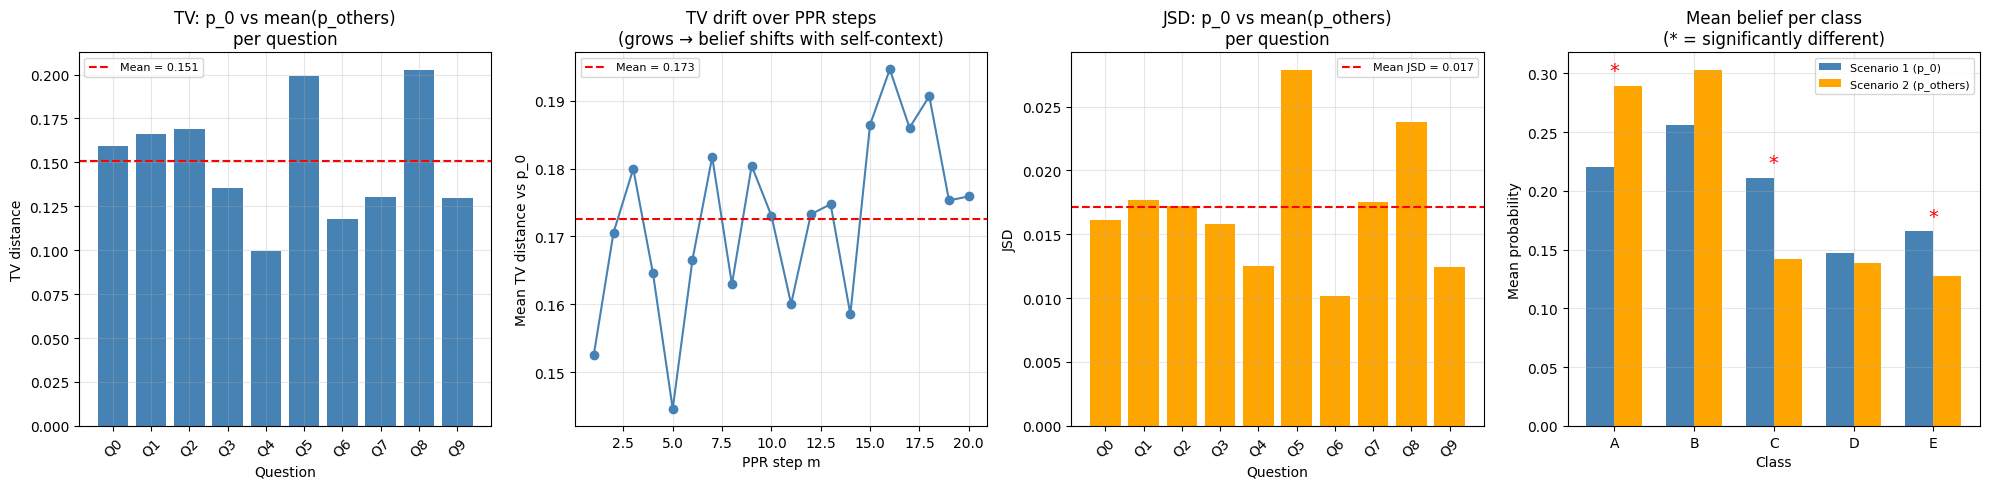

=== Scenario 1 vs Scenario 2 (Figure 2 test) ===
Mean TV distance (p_0 vs mean p_others): 0.1509  (range: 0.100–0.202)
Mean JSD:                                 0.0171  (range: 0.010–0.028)
Global KS test (all steps vs p_0):        stat = 0.1450,  p = 0.0000 *

Paired t-test per class (H0: p_0 == mean(p_others)):
  A: p = 0.0026*  Δ = +0.0691 (↑ in PPR)
  B: p = 0.0525   Δ = +0.0468 (↑ in PPR)
  C: p = 0.0199*  Δ = -0.0695 (↓ in PPR)
  D: p = 0.6176   Δ = -0.0082 (↓ in PPR)
  E: p = 0.0054*  Δ = -0.0382 (↓ in PPR)

Classes with significant shift: 3/5
→ Martingale VIOLATED: model changes beliefs without new evidence.


In [21]:
from scipy import stats
from scipy.special import rel_entr
import numpy as np
import matplotlib.pyplot as plt

def scenario_comparison_test(p_0: np.ndarray, p_others: np.ndarray,
                              alpha: float = 0.05):
    """
    Direct test of the two-scenario comparison (Figure 2).

    p_0     : (Q, C)    — Scenario 1: direct prediction (no self-context)
    p_others: (Q, M, C) — Scenario 2: M PPR steps (self-imputed context)

    Under the martingale property: E_m[p_others[q, m]] = p_0[q] for every q.
    """
    Q, M, C = p_others.shape
    eps          = 1e-9
    class_labels = [chr(65 + c) for c in range(C)]
    steps        = np.arange(1, M + 1)

    # Average over steps for scalar comparisons
    p_others_mean = p_others.mean(axis=1)   # (Q, C)

    # --- TV distance per question (p_0 vs mean of p_others) ---
    tv_mean = 0.5 * np.abs(p_0 - p_others_mean).sum(axis=1)   # (Q,)

    # --- TV distance per step, averaged over questions (Q, M) → (M,) ---
    tv_per_step = 0.5 * np.abs(
        p_0[:, None, :] - p_others          # (Q, M, C)
    ).sum(axis=-1).mean(axis=0)              # (M,)

    # --- JSD per question (p_0 vs p_others_mean) ---
    m_dist = 0.5 * (p_0 + p_others_mean)
    jsd    = 0.5 * (
        rel_entr(p_0,          np.clip(m_dist, eps, 1)).sum(axis=1) +
        rel_entr(p_others_mean, np.clip(m_dist, eps, 1)).sum(axis=1)
    )   # (Q,)

    # --- Paired t-test per class: p_0[:, c] vs p_others_mean[:, c] ---
    ttest_pvals = np.array([
        stats.ttest_rel(p_0[:, c], p_others_mean[:, c]).pvalue
        for c in range(C)
    ])

    # --- Global KS test: pool all Q*M step distributions vs Q p_0s ---
    ks_stat, ks_pval = stats.ks_2samp(
        p_others.reshape(-1, C).ravel(),
        np.tile(p_0, (M, 1)).ravel()
    )

    # --- Plots ---
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # 1. TV distance per question (p_0 vs mean p_others)
    ax = axes[0]
    ax.bar(range(Q), tv_mean, color='steelblue')
    ax.axhline(tv_mean.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean = {tv_mean.mean():.3f}')
    ax.set_xlabel('Question')
    ax.set_ylabel('TV distance')
    ax.set_title('TV: p_0 vs mean(p_others)\nper question')
    ax.set_xticks(range(Q))
    ax.set_xticklabels([f'Q{q}' for q in range(Q)], rotation=45)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # 2. TV distance per step (mean over questions)
    ax = axes[1]
    ax.plot(steps, tv_per_step, marker='o', color='steelblue')
    ax.axhline(tv_per_step.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean = {tv_per_step.mean():.3f}')
    ax.set_xlabel('PPR step m')
    ax.set_ylabel('Mean TV distance vs p_0')
    ax.set_title('TV drift over PPR steps\n(grows → belief shifts with self-context)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # 3. JSD per question
    ax = axes[2]
    ax.bar(range(Q), jsd, color='orange')
    ax.axhline(jsd.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean JSD = {jsd.mean():.3f}')
    ax.set_xlabel('Question')
    ax.set_ylabel('JSD')
    ax.set_title('JSD: p_0 vs mean(p_others)\nper question')
    ax.set_xticks(range(Q))
    ax.set_xticklabels([f'Q{q}' for q in range(Q)], rotation=45)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # 4. Mean probability per class: p_0 vs p_others_mean
    ax = axes[3]
    x = np.arange(C)
    w = 0.35
    ax.bar(x - w/2, p_0.mean(axis=0),          width=w, label='Scenario 1 (p_0)',     color='steelblue')
    ax.bar(x + w/2, p_others_mean.mean(axis=0), width=w, label='Scenario 2 (p_others)', color='orange')
    for c in range(C):
        if ttest_pvals[c] < alpha:
            ymax = max(p_0[:, c].mean(), p_others_mean[:, c].mean()) + 0.008
            ax.text(c, ymax, '*', ha='center', fontsize=14, color='red')
    ax.set_xlabel('Class')
    ax.set_ylabel('Mean probability')
    ax.set_title('Mean belief per class\n(* = significantly different)')
    ax.set_xticks(x)
    ax.set_xticklabels(class_labels)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # --- Summary ---
    print("=== Scenario 1 vs Scenario 2 (Figure 2 test) ===")
    print(f"Mean TV distance (p_0 vs mean p_others): {tv_mean.mean():.4f}  "
          f"(range: {tv_mean.min():.3f}–{tv_mean.max():.3f})")
    print(f"Mean JSD:                                 {jsd.mean():.4f}  "
          f"(range: {jsd.min():.3f}–{jsd.max():.3f})")
    print(f"Global KS test (all steps vs p_0):        stat = {ks_stat:.4f},  "
          f"p = {ks_pval:.4f} {'*' if ks_pval < alpha else ''}")

    print(f"\nPaired t-test per class (H0: p_0 == mean(p_others)):")
    for c in range(C):
        diff = p_others_mean[:, c].mean() - p_0[:, c].mean()
        flag = '*' if ttest_pvals[c] < alpha else ' '
        print(f"  {class_labels[c]}: p = {ttest_pvals[c]:.4f}{flag}  "
              f"Δ = {diff:+.4f} ({'↑' if diff > 0 else '↓'} in PPR)")

    n_sig = (ttest_pvals < alpha).sum()
    print(f"\nClasses with significant shift: {n_sig}/{C}")
    if ks_pval < alpha or n_sig > 0:
        print("→ Martingale VIOLATED: model changes beliefs without new evidence.")
    else:
        print("→ No significant difference between scenarios (martingale consistent).")

# p_0: (Q, C), p_others: (Q, M, C) — use p_all[:, 1:, :] for full step sequence
#p_others_full = p_all[:, 1:, :]   # (10, 20, 5)
scenario_comparison_test(p_0, p_others)


In [ ]:
#dat_q1 = dat['distributions'][0]
dat_q1 = dat['distributions'][0].mean(1)
#dat_q1 = dat['distributions'][0][0]

In [26]:
dat['distributions'].mean(axis=1).mean(axis=0).shape

(101, 5)

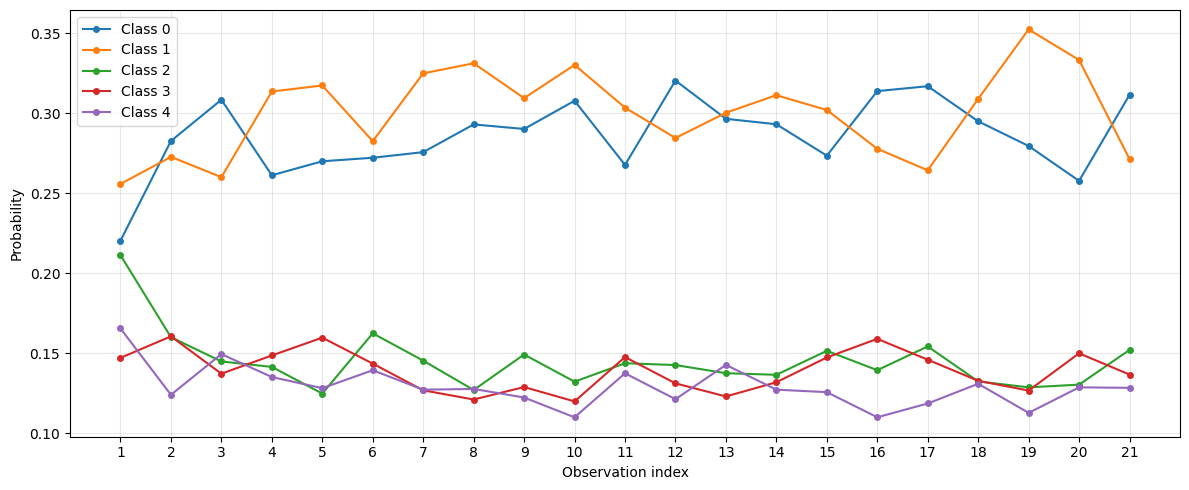

In [22]:
# Distributions of probabilities of classes.
dat_q1 = dat['distributions'].mean(axis=1).mean(axis=0)
n_classes = dat_q1.shape[1]
x = np.arange(1, dat_q1.shape[0]+1)

fig, ax = plt.subplots(figsize=(12, 5))
for c in range(n_classes):
    ax.plot(x, dat_q1[:, c], marker='o', markersize=4, label=f"Class {c}")

ax.set_xlabel("Observation index")
ax.set_ylabel("Probability")
ax.set_xticks(x)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


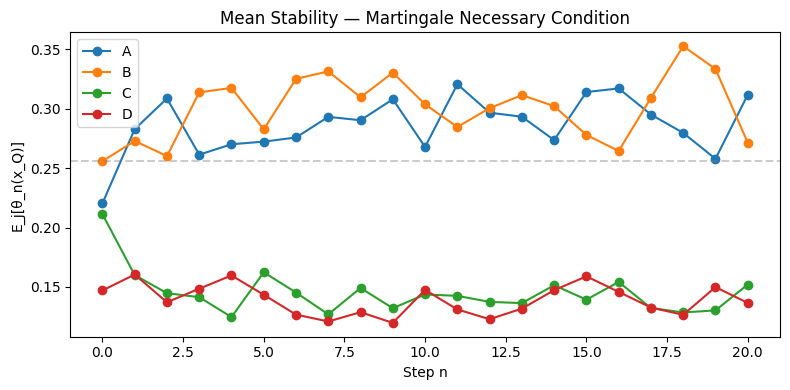

Drift (std of mean across steps): [0.0236 0.0264 0.0181 0.0125 0.0127]
Martingale Score (β̂₁) = 0.2165
  ≈ 0 → martingale holds
  > 0 → belief entrenchment (drift toward prior)


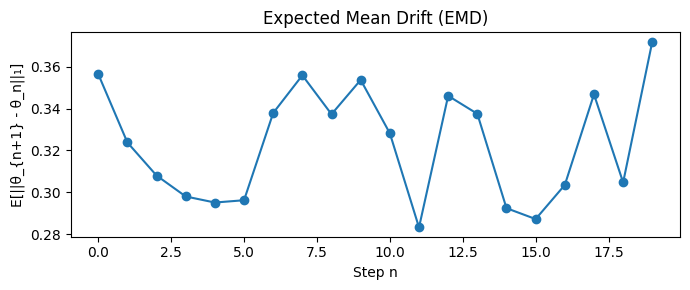

Overall EMD: 0.3232
Early EMD (steps 1-5): 0.3163
Late EMD (steps 15-20): 0.3178


array([0.3565    , 0.3238    , 0.308     , 0.29799995, 0.29510003,
       0.2962    , 0.3379    , 0.35590002, 0.33730006, 0.35369998,
       0.3282    , 0.28320006, 0.3461    , 0.33750004, 0.2924    ,
       0.2872    , 0.30350003, 0.3468    , 0.3047    , 0.37200004],
      dtype=float32)

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# thetas.shape = (J, L, 4)  — J paths, L=20 steps, 4 options
def check_mean_stability(thetas, labels=["A","B","C","D"]):
    # Mean of theta_n across paths at each step
    mean_theta = thetas.mean(axis=0)  # shape (L, 4)

    plt.figure(figsize=(8, 4))
    for k, label in enumerate(labels):
        plt.plot(mean_theta[:, k], marker='o', label=label)
    plt.axhline(mean_theta[0].max(), color='gray', linestyle='--', alpha=0.4)
    plt.xlabel("Step n")
    plt.ylabel("E_j[θ_n(x_Q)]")
    plt.title("Mean Stability — Martingale Necessary Condition")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Quantify: std of the mean across steps (should be ~0)
    drift = mean_theta.std(axis=0)  # per option
    print("Drift (std of mean across steps):", drift.round(4))
    
from sklearn.linear_model import LinearRegression

def martingale_score(thetas):
    """
    Regress theta_{n+1} on theta_n across all paths and consecutive steps.
    Beta_1 ≈ 0  →  martingale holds
    Beta_1 > 0  →  entrenchment / drift
    """
    thetas = thetas.mean(axis=0)  # shape (L, 4)
    J, L, K = thetas.shape
    # Use the max probability (model confidence) as scalar belief b_n
    b = thetas.max(axis=-1)  # shape (J, L)

    X = b[:, :-1].reshape(-1, 1)   # b_n
    y = b[:, 1:].reshape(-1)       # b_{n+1}

    reg = LinearRegression().fit(X, y)
    beta_1 = reg.coef_[0]
    print(f"Martingale Score (β̂₁) = {beta_1:.4f}")
    print("  ≈ 0 → martingale holds")
    print("  > 0 → belief entrenchment (drift toward prior)")
    return beta_1

def expected_mean_drift(thetas):
    """
    EMD = mean over paths and steps of ||θ_{n+1} - θ_n||_1
    Lower is better (closer to martingale).
    """
    # L1 distance between consecutive steps
    thetas = thetas.mean(axis=0)
    diffs = np.abs(thetas[:, 1:, :] - thetas[:, :-1, :]).sum(axis=-1)  # (J, L-1)
    emd_per_step = diffs.mean(axis=0)  # (L-1,)

    plt.figure(figsize=(7, 3))
    plt.plot(emd_per_step, marker='o')
    plt.xlabel("Step n")
    plt.ylabel("E[||θ_{n+1} - θ_n||₁]")
    plt.title("Expected Mean Drift (EMD)")
    plt.tight_layout()
    plt.show()

    print(f"Overall EMD: {emd_per_step.mean():.4f}")
    print(f"Early EMD (steps 1-5): {emd_per_step[:5].mean():.4f}")
    print(f"Late EMD (steps 15-20): {emd_per_step[14:].mean():.4f}")
    return emd_per_step

check_mean_stability(dat['distributions'].mean(axis=1))
martingale_score(dat['distributions'])
expected_mean_drift(dat['distributions'])

/var/folders/k3/dqmr6gz568g4rw3f798jq3mw0000gn/T/ipykernel_56764/2354903918.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


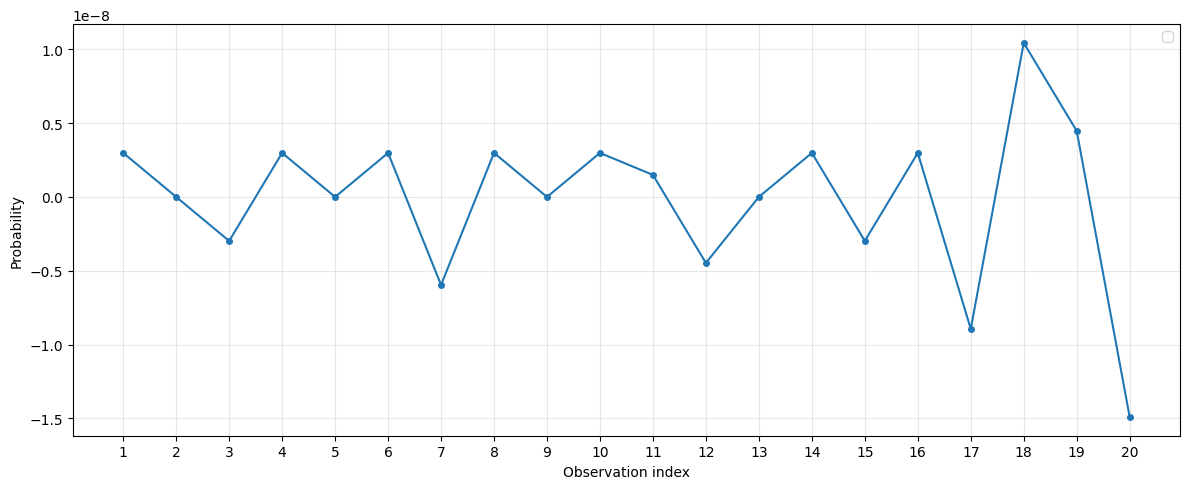

In [41]:
# Lagged Distributions of probabilities of classes.
lagged_diff = np.diff(dat_q1, axis=0).mean(axis = 1)
n_classes = dat_q1.shape[1]
x = np.arange(1, lagged_diff.shape[0]+1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x, lagged_diff, marker='o', markersize=4)
#for c in range(n_classes):
#    ax.plot(x, lagged_diff[:, c], marker='o', markersize=4, label=f"Class {c}")

ax.set_xlabel("Observation index")
ax.set_ylabel("Probability")
ax.set_xticks(x)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [24]:
from scipy import stats
import numpy as np

def family_b_tests_all(dat_distributions: np.ndarray, alpha: float = 0.05):
    """
    dat_distributions : (Q, 2, T, C) — Q questions, 2 seeds, T time steps, C classes.
    Returns per-question results + pooled test.
    """
    Q, _, T, C = dat_distributions.shape

    per_q_deltas = []
    per_q_pvals  = {"ttest": [], "wilcoxon": [], "slope_t": [], "slope_m": []}
    per_q_r2_m   = []

    print(f"{'Q':<4} {'t-pool p':>10} {'Wilcox p':>10} {'slope(t)martingale_check_csqa_qwen2_7b_ppr.sbatch p':>12} {'slope(M) p':>12} {'slope(M) R²':>13}")
    print("-" * 67)

    for q in range(Q):
        seq   = dat_distributions[q].mean(0)   # (T, C) — average over 2 seeds
        delta = np.diff(seq, axis=0)            # (T-1, C)
        t_idx = np.arange(len(delta))
        per_q_deltas.append(delta)

        _, tp  = stats.ttest_1samp(delta.ravel(), popmean=0)
        wp = stats.wilcoxon(delta.ravel()).pvalue

        t_rep  = np.tile(t_idx, C)
        d_flat = delta.T.ravel()
        _, _, _, pt, _ = stats.linregress(t_rep, d_flat)

        m_flat = seq[:-1].T.ravel()
        _, _, r_m, pm, _ = stats.linregress(m_flat, d_flat)
        r2_m = r_m ** 2

        per_q_pvals["ttest"].append(tp)
        per_q_pvals["wilcoxon"].append(wp)
        per_q_pvals["slope_t"].append(pt)
        per_q_pvals["slope_m"].append(pm)
        per_q_r2_m.append(r2_m)

        flag = lambda p: "*" if p < alpha else " "
        print(f"Q{q:<3} {tp:>9.4f}{flag(tp)} {wp:>9.4f}{flag(wp)} "
              f"{pt:>11.4f}{flag(pt)} {pm:>11.4f}{flag(pm)} {r2_m:>13.4f}")

    # --- Per-class, per-question regressions (no class pooling) ---
    per_class_pvals = np.zeros((Q, C))
    per_class_r2    = np.zeros((Q, C))
    for q in range(Q):
        seq   = dat_distributions[q].mean(0)
        delta = np.diff(seq, axis=0)
        for c in range(C):
            _, _, r_c, p_c, _ = stats.linregress(seq[:-1, c], delta[:, c])
            per_class_pvals[q, c] = p_c
            per_class_r2[q, c]    = r_c ** 2

    # --- Pooled analysis: stack all increments ---
    all_delta = np.vstack(per_q_deltas)
    _, tp_pool = stats.ttest_1samp(all_delta.ravel(), popmean=0)
    wp_pool    = stats.wilcoxon(all_delta.ravel()).pvalue

    def fishers(pvals):
        pvals = np.clip(pvals, 1e-300, 1)
        stat = -2 * np.sum(np.log(pvals))
        return stats.chi2.sf(stat, df=2 * len(pvals))

    print("\n--- Global summary ---")
    print(f"Pooled t-test   (all Q, all C): p = {tp_pool:.4f} {'*' if tp_pool < alpha else ''}")
    print(f"Pooled Wilcoxon (all Q, all C): p = {wp_pool:.4f} {'*' if wp_pool < alpha else ''}")
    print(f"Fisher combined t-test p-vals:   p = {fishers(per_q_pvals['ttest']):.4f}")
    print(f"Fisher combined slope(t) p-vals: p = {fishers(per_q_pvals['slope_t']):.4f}")
    print(f"Fisher combined slope(M) p-vals (pooled classes): p = {fishers(per_q_pvals['slope_m']):.4f}  mean R² = {np.mean(per_q_r2_m):.4f}")

    print(f"\n--- slope(M) per class (no class pooling, {T-1} obs per cell) ---")
    cls_labels = [f"C{c}" for c in range(C)]
    print(f"{'':6}" + "".join(f"  {l:>9}" for l in cls_labels))
    for q in range(Q):
        row = f"Q{q:<5}"
        for c in range(C):
            flag = "*" if per_class_pvals[q, c] < alpha else " "
            row += f"  {per_class_pvals[q, c]:>8.4f}{flag}"
        print(row)

    print(f"\nFisher p (per class, across Q):")
    for c in range(C):
        fp   = fishers(per_class_pvals[:, c])
        flag = "*" if fp < alpha else " "
        print(f"  C{c}: p = {fp:.4f}{flag}  mean R² = {per_class_r2[:, c].mean():.4f}")

    fisher_all = fishers(per_class_pvals.ravel())
    print(f"\nFisher combined (all Q × C, no pooling): p = {fisher_all:.4f} {'*' if fisher_all < alpha else ''}")
    print(f"Mean R² (all Q × C, no pooling):         R² = {per_class_r2.mean():.4f}")

family_b_tests_all(dat['distributions'])


Q      t-pool p   Wilcox p slope(t)martingale_check_csqa_qwen2_7b_ppr.sbatch p   slope(M) p   slope(M) R²
-------------------------------------------------------------------
Q0      1.0000     0.6699       1.0000       0.0000*        0.1608
Q1      1.0000     0.7641       1.0000       0.0017*        0.0966
Q2      1.0000     0.5728       1.0000       0.0013*        0.1009
Q3      1.0000     0.7508       1.0000       0.0000*        0.1640
Q4      1.0000     0.8368       1.0000       0.0610         0.0354
Q5      1.0000     0.6290       1.0000       0.0000*        0.1781
Q6      1.0000     0.7426       1.0000       0.0115*        0.0635
Q7      1.0000     0.6792       1.0000       0.0082*        0.0692
Q8      1.0000     0.9753       1.0000       0.0016*        0.0969
Q9      1.0000     0.9346       1.0000       0.0017*        0.0964

--- Global summary ---
Pooled t-test   (all Q, all C): p = 1.0000 
Pooled Wilcoxon (all Q, all C): p = 0.6635 
Fisher combined t-test p-vals:   p = 1.0000


In [25]:
def family_b_tests_logit(dat_distributions: np.ndarray, alpha: float = 0.05, eps: float = 1e-6):
    """
    Same as family_b_tests_all but in CLR (centered log-ratio) space.
    Removes the simplex boundary artifact from the slope(M) test.
    dat_distributions : (Q, 2, T, C)
    """
    Q, _, T, C = dat_distributions.shape

    def to_clr(p):
        p = np.clip(p, eps, 1)
        log_p = np.log(p)
        return log_p - log_p.mean(axis=-1, keepdims=True)

    per_q_deltas = []
    per_q_pvals  = {"ttest": [], "wilcoxon": [], "slope_t": [], "slope_m": []}
    per_q_r2_m   = []

    print(f"{'Q':<4} {'t-test p':>10} {'Wilcox p':>10} {'slope(t) p':>12} {'slope(M) p':>12} {'slope(M) R²':>13}")
    print("-" * 67)

    for q in range(Q):
        seq_prob = dat_distributions[q].mean(0)   # (T, C)
        seq_clr  = to_clr(seq_prob)               # (T, C) — CLR space
        delta    = np.diff(seq_clr, axis=0)        # (T-1, C)
        t_idx    = np.arange(len(delta))
        per_q_deltas.append(delta)

        _, tp = stats.ttest_1samp(delta.ravel(), popmean=0)
        wp    = stats.wilcoxon(delta.ravel()).pvalue

        t_rep  = np.tile(t_idx, C)
        d_flat = delta.T.ravel()
        _, _, _, pt, _ = stats.linregress(t_rep, d_flat)

        m_flat = seq_clr[:-1].T.ravel()
        _, _, r_m, pm, _ = stats.linregress(m_flat, d_flat)
        r2_m = r_m ** 2

        per_q_pvals["ttest"].append(tp)
        per_q_pvals["wilcoxon"].append(wp)
        per_q_pvals["slope_t"].append(pt)
        per_q_pvals["slope_m"].append(pm)
        per_q_r2_m.append(r2_m)

        flag = lambda p: "*" if p < alpha else " "
        print(f"Q{q:<3} {tp:>9.4f}{flag(tp)} {wp:>9.4f}{flag(wp)} "
              f"{pt:>11.4f}{flag(pt)} {pm:>11.4f}{flag(pm)} {r2_m:>13.4f}")

    # --- Per-class, per-question regressions (no class pooling) ---
    per_class_pvals = np.zeros((Q, C))
    per_class_r2    = np.zeros((Q, C))
    for q in range(Q):
        seq_prob = dat_distributions[q].mean(0)
        seq_clr  = to_clr(seq_prob)
        delta    = np.diff(seq_clr, axis=0)
        for c in range(C):
            _, _, r_c, p_c, _ = stats.linregress(seq_clr[:-1, c], delta[:, c])
            per_class_pvals[q, c] = p_c
            per_class_r2[q, c]    = r_c ** 2

    all_delta = np.vstack(per_q_deltas)
    _, tp_pool = stats.ttest_1samp(all_delta.ravel(), popmean=0)
    wp_pool    = stats.wilcoxon(all_delta.ravel()).pvalue

    def fishers(pvals):
        pvals = np.clip(pvals, 1e-300, 1)
        stat = -2 * np.sum(np.log(pvals))
        return stats.chi2.sf(stat, df=2 * len(pvals))

    print("\n--- Global summary (CLR space) ---")
    print(f"Pooled t-test:            p = {tp_pool:.4f} {'*' if tp_pool < alpha else ''}")
    print(f"Pooled Wilcoxon:          p = {wp_pool:.4f} {'*' if wp_pool < alpha else ''}")
    print(f"Fisher combined t-test:   p = {fishers(per_q_pvals['ttest']):.4f}")
    print(f"Fisher combined slope(t): p = {fishers(per_q_pvals['slope_t']):.4f}")
    print(f"Fisher combined slope(M) (pooled classes): p = {fishers(per_q_pvals['slope_m']):.4f}  mean R² = {np.mean(per_q_r2_m):.4f}")

    print(f"\n--- slope(M) per class in CLR space (no class pooling, {T-1} obs per cell) ---")
    cls_labels = [f"C{c}" for c in range(C)]
    print(f"{'':6}" + "".join(f"  {l:>9}" for l in cls_labels))
    for q in range(Q):
        row = f"Q{q:<5}"
        for c in range(C):
            flag = "*" if per_class_pvals[q, c] < alpha else " "
            row += f"  {per_class_pvals[q, c]:>8.4f}{flag}"
        print(row)

    print(f"\nFisher p (per class, across Q):")
    for c in range(C):
        fp   = fishers(per_class_pvals[:, c])
        flag = "*" if fp < alpha else " "
        print(f"  C{c}: p = {fp:.4f}{flag}  mean R² = {per_class_r2[:, c].mean():.4f}")

    fisher_all = fishers(per_class_pvals.ravel())
    print(f"\nFisher combined (all Q × C, no pooling): p = {fisher_all:.4f} {'*' if fisher_all < alpha else ''}")
    print(f"Mean R² (all Q × C, no pooling):         R² = {per_class_r2.mean():.4f}")

family_b_tests_logit(dat['distributions'])


Q      t-test p   Wilcox p   slope(t) p   slope(M) p   slope(M) R²
-------------------------------------------------------------------
Q0      1.0000     0.6450       1.0000       0.0000*        0.1639
Q1      1.0000     0.8339       1.0000       0.0009*        0.1060
Q2      1.0000     0.6303       1.0000       0.0010*        0.1060
Q3      1.0000     0.7939       1.0000       0.0000*        0.1701
Q4      1.0000     0.8743       1.0000       0.0107*        0.0646
Q5      1.0000     0.7518       1.0000       0.0000*        0.1554
Q6      1.0000     0.8716       1.0000       0.0057*        0.0754
Q7      1.0000     0.7886       1.0000       0.0051*        0.0771
Q8      1.0000     0.9863       1.0000       0.0007*        0.1115
Q9      1.0000     0.8608       1.0000       0.0007*        0.1118

--- Global summary (CLR space) ---
Pooled t-test:            p = 1.0000 
Pooled Wilcoxon:          p = 0.7014 
Fisher combined t-test:   p = 1.0000
Fisher combined slope(t): p = 1.0000
Fisher co

In [46]:
from scipy import stats
import numpy as np

def martingale_score(dat: np.ndarray, per_class: bool = False):
    """
    dat : (N, C) — first row is b_prior, remaining N-1 rows are posteriors
    """
    b_prior = dat[0]          # (C,)
    b_post  = dat[1:]         # (N-1, C)
    delta_b = b_post - b_prior  # (N-1, C)

    if per_class:
        Ms, p_vals = [], []
        for c in range(dat.shape[1]):
            # x is a constant (same prior for all posteriors), so we regress
            # delta_b[:, c] on the scalar b_prior[c] — use the pooled approach instead
            slope, _, _, p, _ = stats.linregress(
                np.full(len(b_post), b_prior[c]), delta_b[:, c]
            )
            Ms.append(slope)
            p_vals.append(p)
        return {"M": np.array(Ms), "p_value": np.array(p_vals)}
    else:
        # Pool across all posteriors and classes
        x = np.tile(b_prior, len(b_post))   # repeat b_prior for each posterior row
        y = delta_b.flatten()
        slope, _, _, p, _ = stats.linregress(x, y)
        return {"M": slope, "p_value": p}


result = martingale_score(dat_q1)
print(f"M (pooled): {result['M']:.4f},  p-value: {result['p_value']:.100f}")
print(f"Significant (p<0.05): {result['p_value'] < 0.05}")


M (pooled): 0.6514,  p-value: 0.0000007854792762861846237626081701499458631587913259863853454589843750000000000000000000000000000000
Significant (p<0.05): True


In [153]:
!pip install statsmodels

Class         LB stat    p-value   Independent?
------------------------------------------------
A              4.1169     0.5327            YES
B              5.9131     0.3148            YES
C              5.3368     0.3762            YES
D              3.7143     0.5912            YES
E             11.7664     0.0381             NO


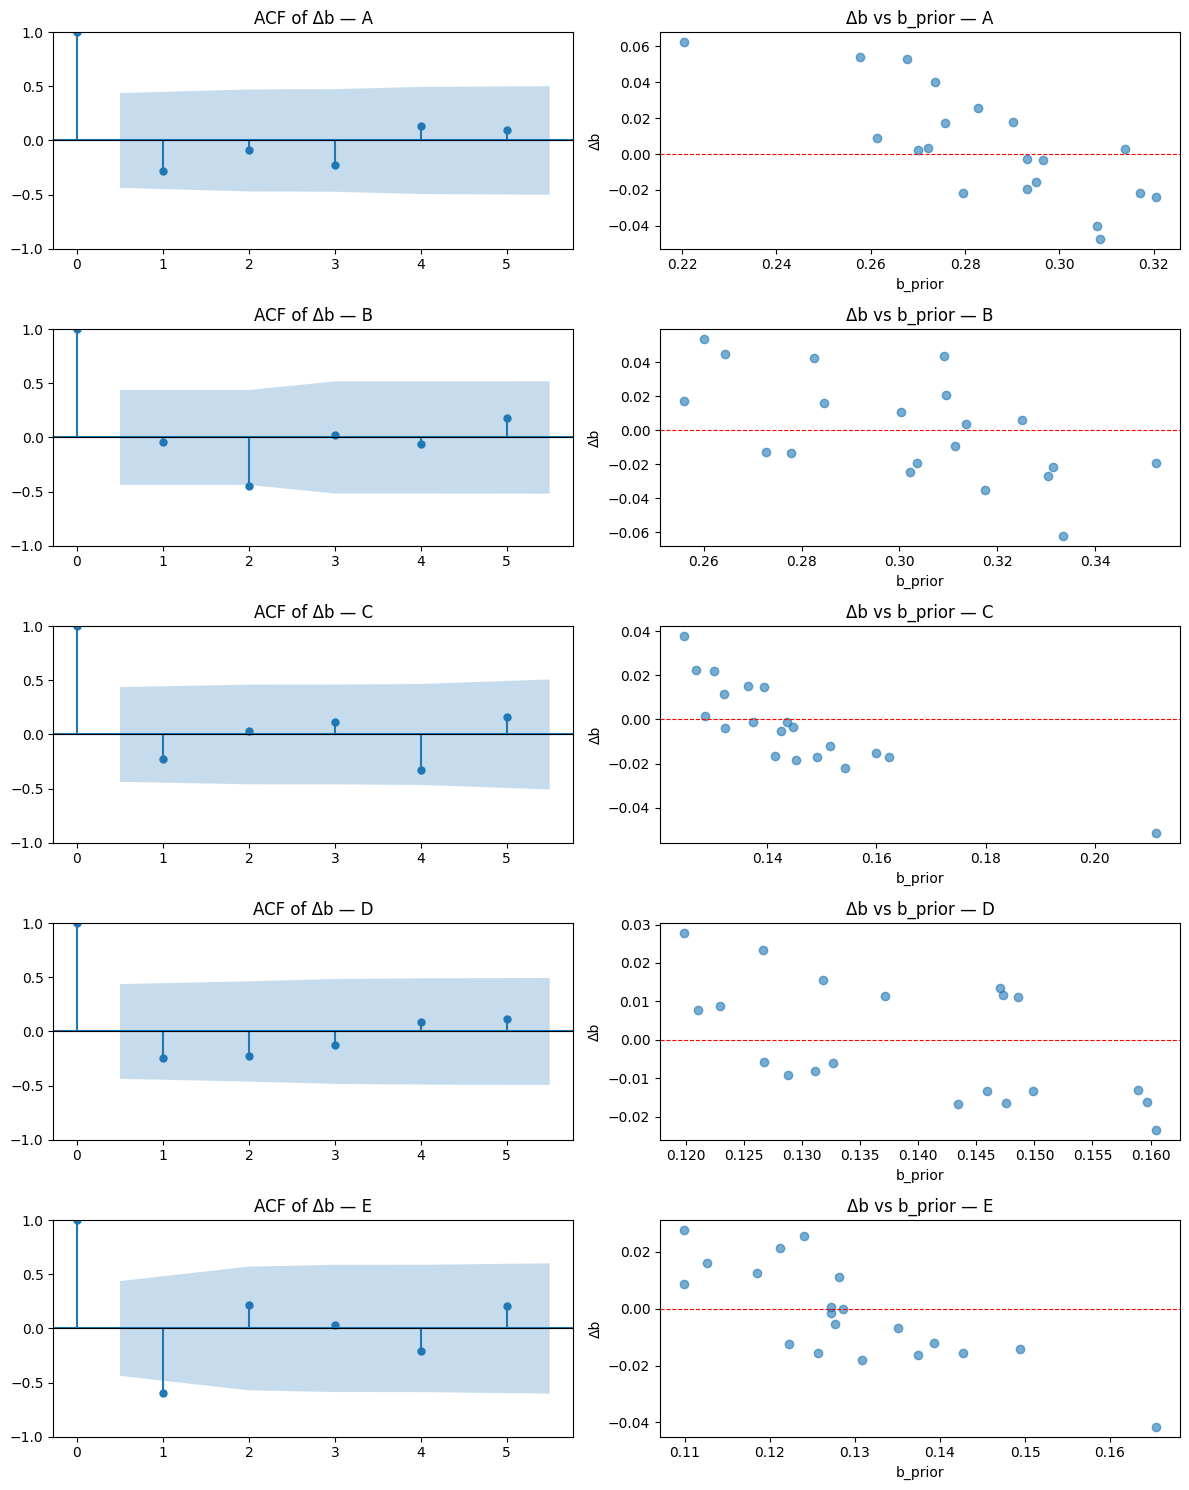

In [26]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
import numpy as np

def test_independence(dat: np.ndarray, lags: int = 5, labels=None):
    """
    dat    : (T, C) — probability distributions over time
    lags   : number of lags for Ljung-Box test
    labels : class label names, e.g. ['A','B','C','D','E']
    """
    T, C = dat.shape
    delta_b = np.diff(dat, axis=0)  # (T-1, C)  — belief updates

    if labels is None:
        labels = [f"Class {c}" for c in range(C)]

    fig, axes = plt.subplots(C, 2, figsize=(12, 3 * C))

    print(f"{'Class':<10} {'LB stat':>10} {'p-value':>10} {'Independent?':>14}")
    print("-" * 48)

    for c in range(C):
        series = delta_b[:, c]

        # --- Ljung-Box test ---
        lb = acorr_ljungbox(series, lags=[lags], return_df=True)
        stat  = lb["lb_stat"].values[0]
        pval  = lb["lb_pvalue"].values[0]
        indep = "YES" if pval > 0.05 else "NO"
        print(f"{labels[c]:<10} {stat:>10.4f} {pval:>10.4f} {indep:>14}")

        # --- ACF plot of Δb ---
        plot_acf(series, lags=min(lags, len(series) // 2), ax=axes[c, 0], title=f"ACF of Δb — {labels[c]}")
        axes[c, 0].axhline(0, color='black', linewidth=0.8)

        # --- Δb vs b_prior (Martingale Score relationship) ---
        axes[c, 1].scatter(dat[:-1, c], series, alpha=0.6)
        axes[c, 1].axhline(0, color='red', linestyle='--', linewidth=0.8)
        axes[c, 1].set_xlabel("b_prior")
        axes[c, 1].set_ylabel("Δb")
        axes[c, 1].set_title(f"Δb vs b_prior — {labels[c]}")

    plt.tight_layout()
    plt.show()

test_independence(dat_q1, lags=5, labels=['A', 'B', 'C', 'D', 'E'])
